In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string

from collections import Counter
from wordcloud import WordCloud

In [4]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kithm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kithm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kithm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df = pd.read_csv("../data/sms_spam_collection.csv")

In [6]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.columns

Index(['label', 'message'], dtype='str')

In [8]:
df = df[["label", "message"]].copy()

In [9]:
df.columns = ["label", "message"]

In [10]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.columns

Index(['label', 'message'], dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB


In [13]:
df.sample(10, random_state=42)

,label,message
3245,ham,Squeeeeeze!! This is christmas hug.. If u lik ...
944,ham,And also I've sorta blown him off a couple tim...
1044,ham,Mmm thats better now i got a roast down me! i...
2484,ham,Mm have some kanji dont eat anything heavy ok
812,ham,So there's a ring that comes with the guys cos...
2973,ham,Sary just need Tim in the bollox &it hurt him ...
2991,ham,"Love isn't a decision, it's a feeling. If we c..."
2942,ham,My supervisor find 4 me one lor i thk his stud...
230,ham,Dear good morning now only i am up
1181,ham,I'm in chennai velachery:)


In [14]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [15]:
missing_percentage = df.isnull().mean() * 100
missing_percentage

label      0.0
message    0.0
dtype: float64

No missing values were detected in the label or message columns.

In [16]:
df.duplicated().sum()

np.int64(403)

In [17]:
df["message"].duplicated().sum()

np.int64(403)

In [18]:
df[df.duplicated(subset="message", keep=False)].sort_values("message").head(20)

,label,message
505,spam,+123 Congratulations - in this week's competit...
2124,spam,+123 Congratulations - in this week's competit...
1373,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2163,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2344,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1050,spam,18 days to Euro2004 kickoff! U will be kept in...
2719,spam,18 days to Euro2004 kickoff! U will be kept in...
389,spam,4mths half price Orange line rental & latest c...
2044,spam,4mths half price Orange line rental & latest c...
1470,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...


In [19]:
df_clean = df.drop_duplicates(subset="message").copy()

In [20]:
df_clean.shape

(5169, 2)

In [21]:
df_clean["message"].duplicated().sum()

np.int64(0)

Duplicate SMS messages were identified and removed to reduce repeated information and prevent duplicate samples from influencing model training and evaluation.

In [22]:
class_counts = df_clean["label"].value_counts()
class_counts

label
ham     4516
spam     653
Name: count, dtype: int64

In [23]:
class_percentages = df_clean["label"].value_counts(normalize=True) * 100
class_percentages.round(2)

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64

In [24]:
class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

class_distribution

,Count,Percentage
label,,
ham,4516,87.37
spam,653,12.63


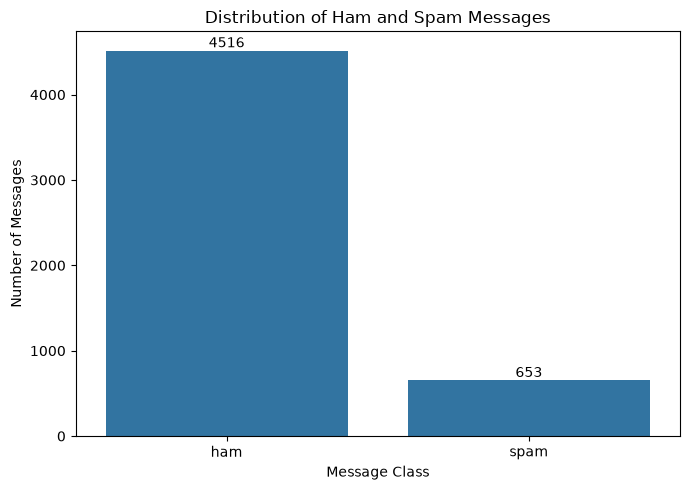

In [25]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="label"
)

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Class")
plt.ylabel("Number of Messages")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

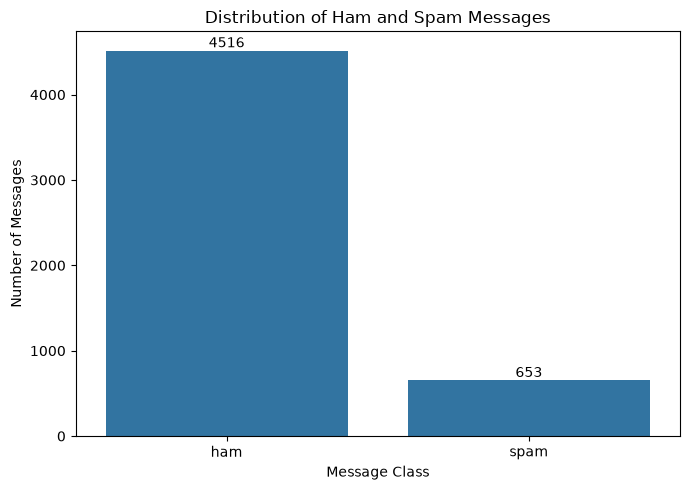

In [26]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="label"
)

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Class")
plt.ylabel("Number of Messages")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(
    "../images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [27]:
df_clean["character_count"] = df_clean["message"].str.len()

df_clean["word_count"] = df_clean["message"].apply(
    lambda text: len(nltk.word_tokenize(str(text)))
)

df_clean["sentence_count"] = df_clean["message"].apply(
    lambda text: len(nltk.sent_tokenize(str(text)))
)

In [28]:
df_clean.head()

,label,message,character_count,word_count,sentence_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [29]:
df_clean[
    ["character_count", "word_count", "sentence_count"]
].describe()

,character_count,word_count,sentence_count
count,5169.000000,5169.000000,5169.000000
mean,79.344941,18.593925,1.974076
std,58.439256,13.403137,1.458967
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,119.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
df_clean.groupby("label")[
    ["character_count", "word_count", "sentence_count"]
].agg(["mean", "median", "min", "max", "std"]).round(2)

character_count                        word_count                  \
                 mean median min  max    std       mean median min  max   
label                                                                     
ham             70.91   53.0   2  910  56.72      17.27   13.0   1  220   
spam           137.70  148.0  13  223  29.82      27.76   29.0   2   46   

             sentence_count                       
         std           mean median min max   std  
label                                             
ham    13.59           1.83    1.0   1  38  1.39  
spam    6.99           2.99    3.0   1   9  1.49

In [31]:
average_features = df_clean.groupby("label")[
    ["character_count", "word_count", "sentence_count"]
].mean().round(2)

average_features

,character_count,word_count,sentence_count
label,,,
ham,70.91,17.27,1.83
spam,137.70,27.76,2.99


Spam messages tend to contain more characters and words than ham messages. This suggests that message length may help distinguish spam from normal SMS messages.

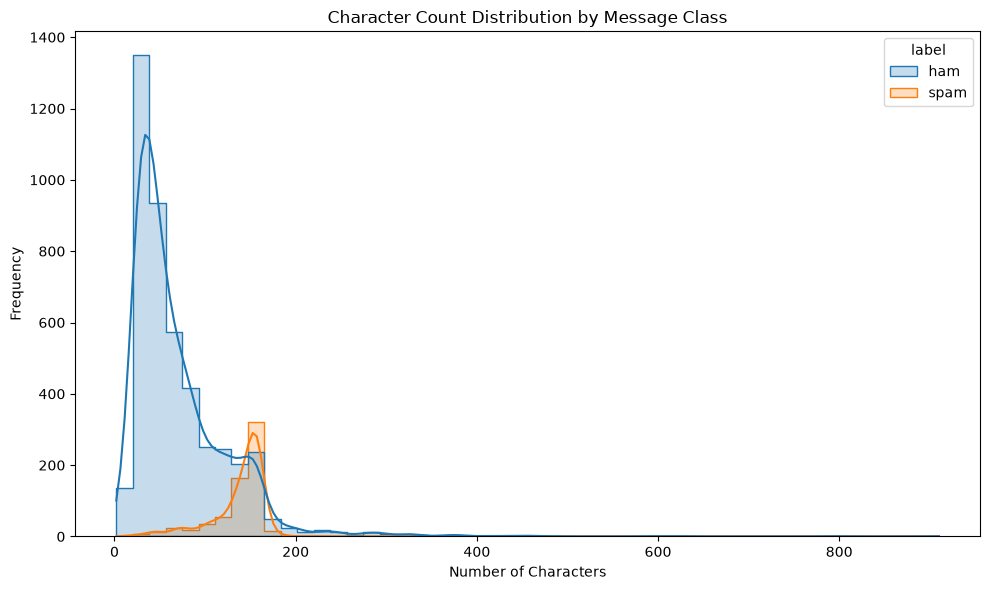

In [32]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="character_count",
    hue="label",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Character Count Distribution by Message Class")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

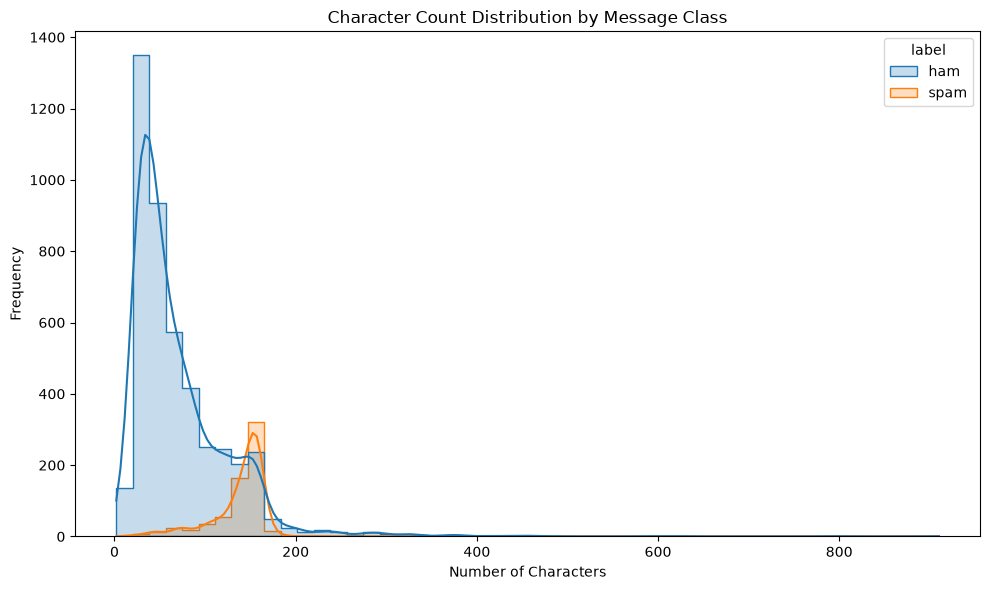

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="character_count",
    hue="label",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Character Count Distribution by Message Class")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    "../images/character_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

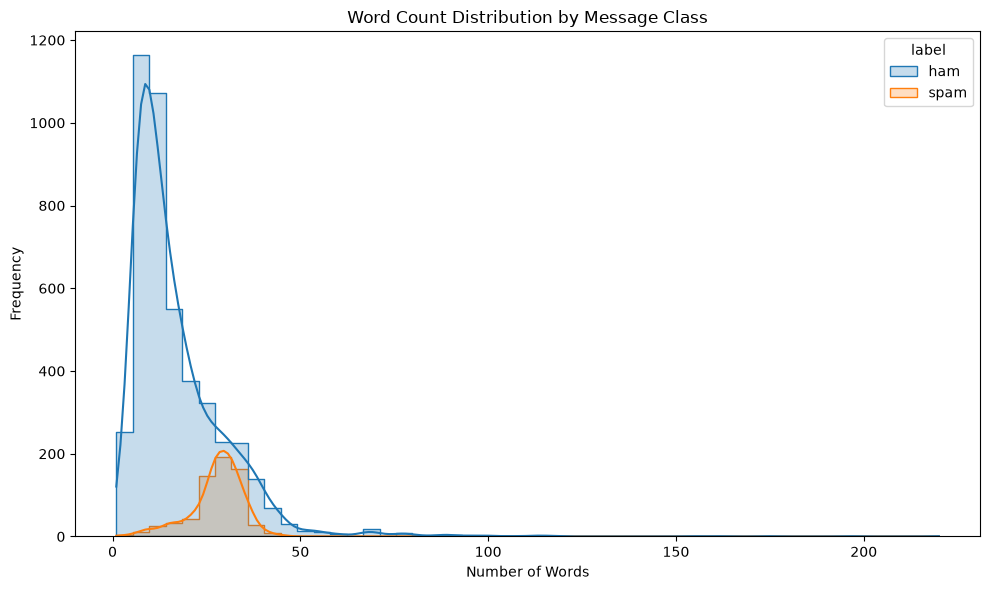

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="word_count",
    hue="label",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Word Count Distribution by Message Class")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

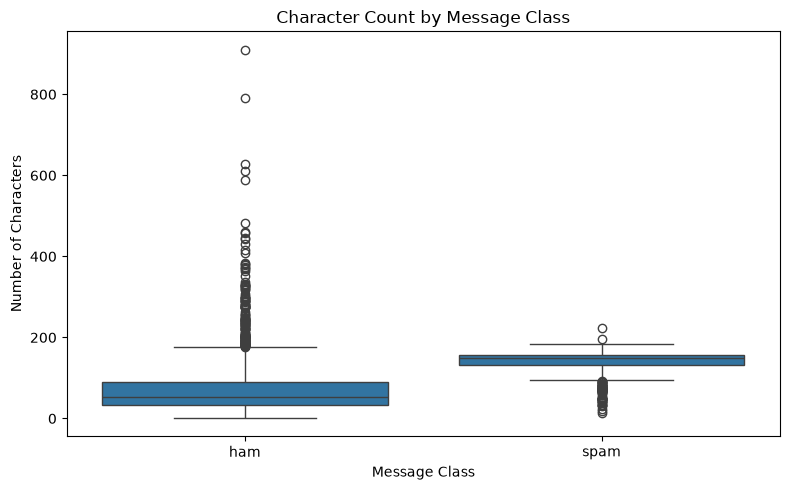

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="character_count"
)

plt.title("Character Count by Message Class")
plt.xlabel("Message Class")
plt.ylabel("Number of Characters")
plt.tight_layout()
plt.show()

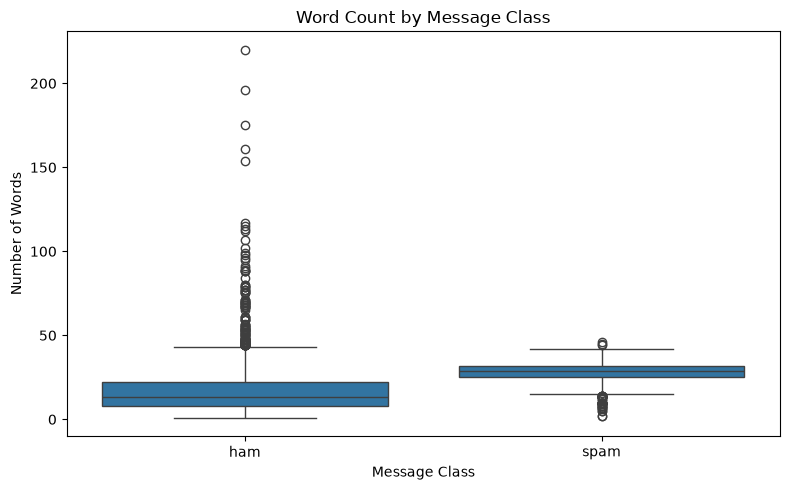

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="word_count"
)

plt.title("Word Count by Message Class")
plt.xlabel("Message Class")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

In [37]:
numeric_columns = [
    "character_count",
    "word_count",
    "sentence_count"
]

correlation_matrix = df_clean[numeric_columns].corr()
correlation_matrix

,character_count,word_count,sentence_count
character_count,1.000000,0.965988,0.622566
word_count,0.965988,1.000000,0.679164
sentence_count,0.622566,0.679164,1.000000


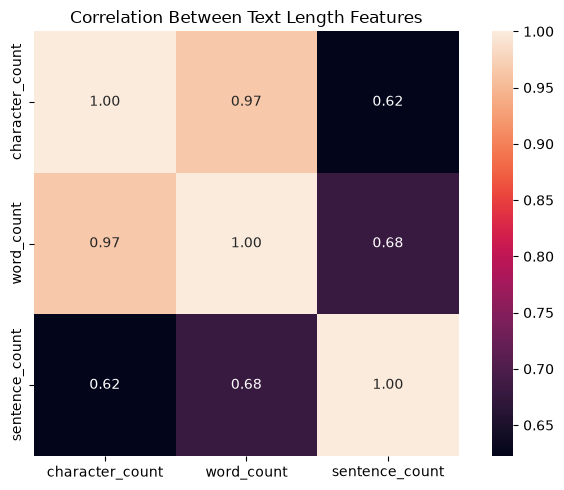

In [38]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Between Text Length Features")
plt.tight_layout()
plt.show()

In [39]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def prepare_words_for_eda(text):
    text = str(text).lower()
    words = nltk.word_tokenize(text)

    cleaned_words = []

    for word in words:
        if word.isalpha() and word not in stop_words:
            cleaned_words.append(word)

    return cleaned_words

In [40]:
prepare_words_for_eda("Congratulations! You have won a FREE prize today.")

['congratulations', 'free', 'prize', 'today']

In [41]:
ham_words = []

for message in df_clean[df_clean["label"] == "ham"]["message"]:
    ham_words.extend(prepare_words_for_eda(message))

In [42]:
ham_word_counts = Counter(ham_words)
ham_word_counts.most_common(20)

[('u', 897),
 ('get', 294),
 ('gt', 288),
 ('lt', 287),
 ('go', 243),
 ('got', 239),
 ('know', 226),
 ('like', 223),
 ('ok', 218),
 ('good', 214),
 ('come', 214),
 ('ur', 203),
 ('time', 189),
 ('call', 186),
 ('love', 178),
 ('ü', 173),
 ('day', 171),
 ('going', 164),
 ('want', 160),
 ('lor', 159)]

In [43]:
ham_common_words = pd.DataFrame(
    ham_word_counts.most_common(20),
    columns=["word", "count"]
)

ham_common_words

,word,count
0,u,897
1,get,294
2,gt,288
3,lt,287
4,go,243
5,got,239
6,know,226
7,like,223
8,ok,218
9,good,214


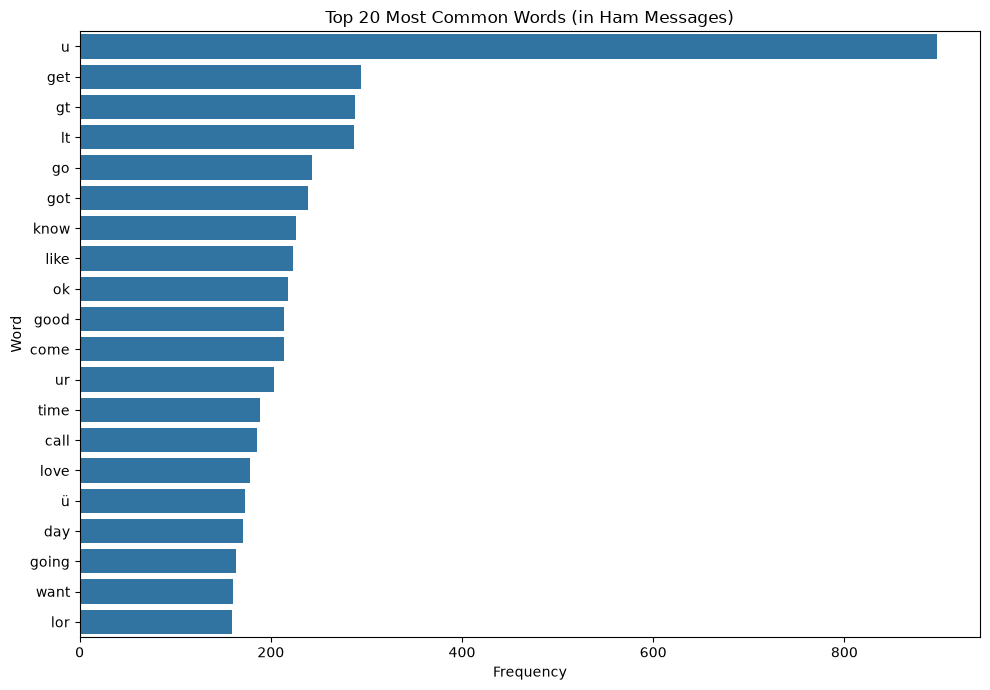

In [44]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=ham_common_words,
    x="count",
    y="word"
)

plt.title("Top 20 Most Common Words (in Ham Messages)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

In [45]:
spam_words = []

for message in df_clean[df_clean["label"] == "spam"]["message"]:
    spam_words.extend(prepare_words_for_eda(message))

In [46]:
spam_word_counts = Counter(spam_words)
spam_word_counts.most_common(20)

[('call', 302),
 ('free', 191),
 ('txt', 130),
 ('u', 120),
 ('ur', 119),
 ('stop', 108),
 ('mobile', 105),
 ('text', 104),
 ('claim', 96),
 ('reply', 96),
 ('prize', 81),
 ('get', 70),
 ('new', 64),
 ('send', 59),
 ('urgent', 58),
 ('nokia', 54),
 ('cash', 51),
 ('contact', 51),
 ('please', 49),
 ('service', 48)]

In [47]:
spam_common_words = pd.DataFrame(
    spam_word_counts.most_common(20),
    columns=["word", "count"]
)

spam_common_words

,word,count
0,call,302
1,free,191
2,txt,130
3,u,120
4,ur,119
5,stop,108
6,mobile,105
7,text,104
8,claim,96
9,reply,96


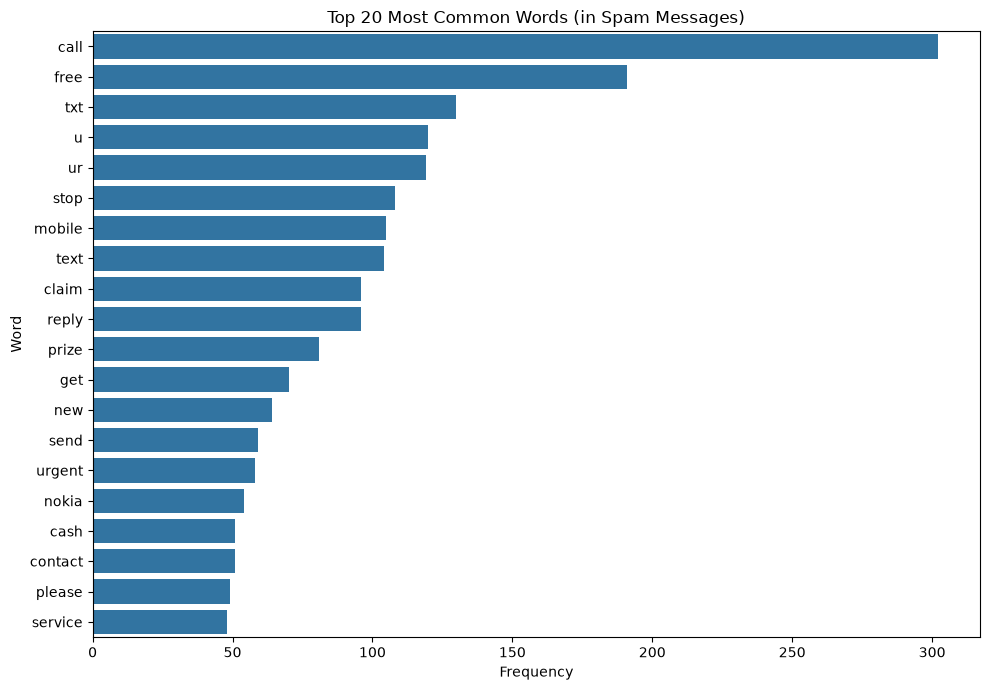

In [48]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=spam_common_words,
    x="count",
    y="word"
)

plt.title("Top 20 Most Common Words (in Spam Messages)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

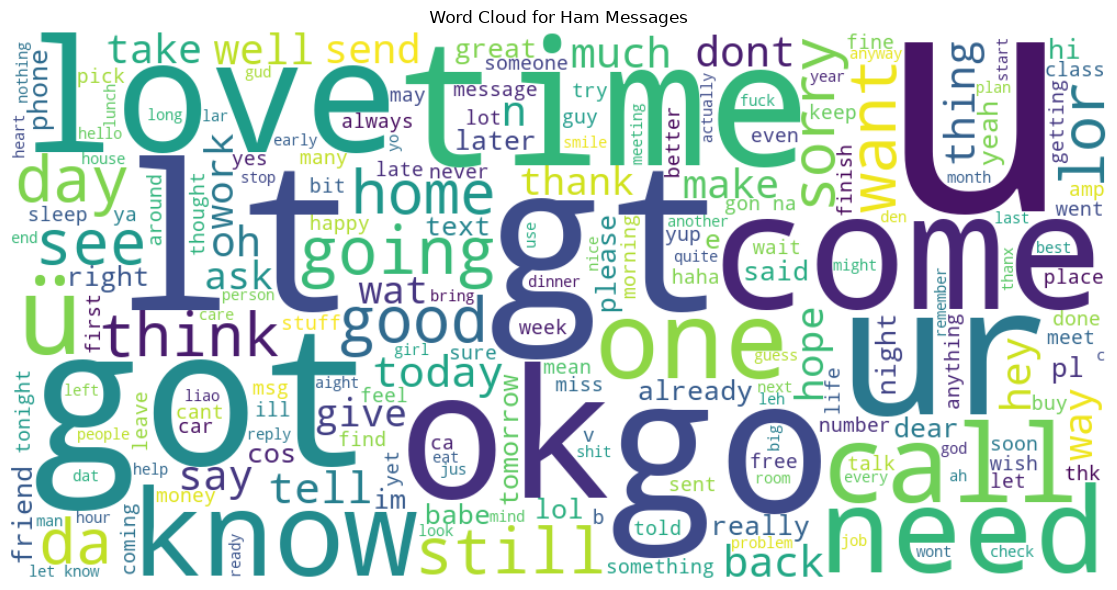

In [49]:
ham_text = " ".join(ham_words)

ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Ham Messages")
plt.tight_layout()
plt.show()

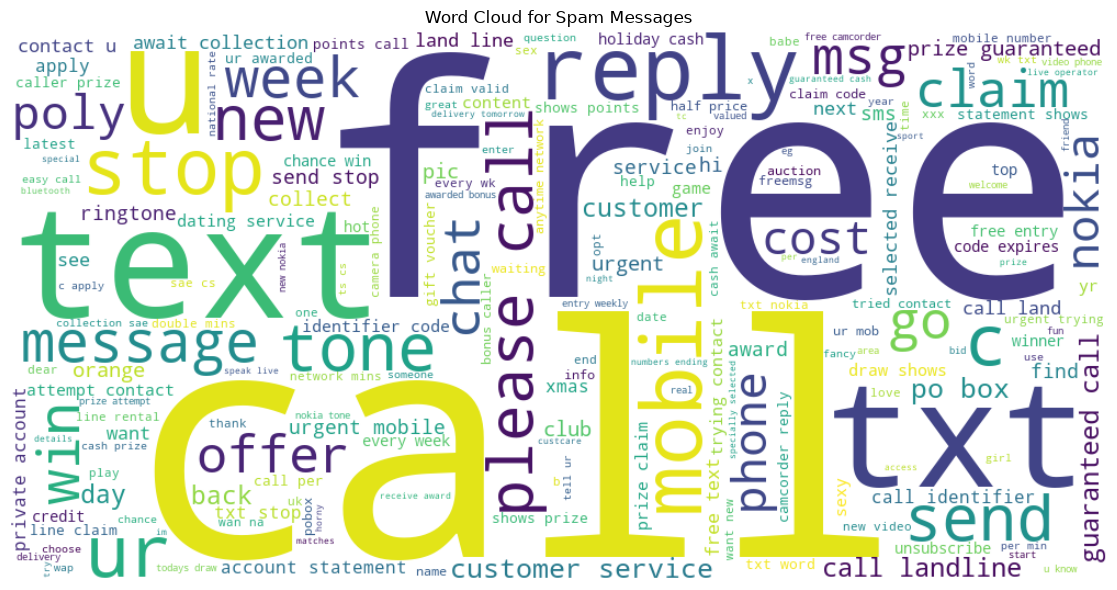

In [50]:
spam_text = " ".join(spam_words)

spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Spam Messages")
plt.tight_layout()
plt.show()

In [51]:
pd.set_option("display.max_colwidth", None)

df_clean[df_clean["label"] == "ham"][
    ["message", "character_count", "word_count"]
].sample(5, random_state=42)

,message,character_count,word_count
1883,"Sorry, I can't help you on this.",32,10
1709,"How's my loverboy doing ? What does he do that keeps him from coming to his Queen, hmmm ? Doesn't he ache to speak to me ? Miss me desparately ?",144,34
4919,Sitting in mu waiting for everyone to get out of my suite so I can take a shower,80,18
1297,Sure! I am driving but will reach my destination soon.,54,12
3948,"Sorry, went to bed early, nightnight",36,8


In [52]:
df_clean[df_clean["label"] == "spam"][
    ["message", "character_count", "word_count"]
].sample(5, random_state=42)

,message,character_count,word_count
761,"Romantic Paris. 2 nights, 2 flights from £79 Book now 4 next year. Call 08704439680Ts&Cs apply.",95,22
2064,"URGENT! Your mobile No *********** WON a £2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! Call 09066362220 ASAP! BOX97N7QP, 150ppm",158,41
1444,Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or £250 cash every wk. Txt POD to 84128 Ts&Cs www.textpod.net custcare 08712405020.,140,30
3496,"Wan2 win a Meet+Greet with Westlife 4 U or a m8? They are currently on what tour? 1)Unbreakable, 2)Untamed, 3)Unkempt. Text 1,2 or 3 to 83049. Cost 50p +std text",161,42
3642,"You can stop further club tones by replying ""STOP MIX"" See my-tone.com/enjoy. html for terms. Club tones cost GBP4.50/week. MFL, PO Box 1146 MK45 2WT (2/3)",155,34


In [53]:
df_clean.to_csv(
    "../data/sms_spam_cleaned.csv",
    index=False
)

The SMS Spam Collection dataset was examined before model development.

In this notebook I did,

1. The dataset contains two target classes: ham and spam.
2. Ham messages significantly outnumber spam messages showing a class imbalance.
3. Missing values were checked before analysis.
4. Duplicate SMS messages were identified and removed.
5. Message level features such as character count, word count and sentence count were created.
6. Spam and ham messages showed differences in their length distributions.
7. Common word analysis revealed different vocabulary patterns between spam and ham messages.
8. Because the dataset is imbalanced accuracy alone will not be sufficient for model evaluation. Precision, recall, F1-score and the confusion matrix will also be used.

The next stage is text preprocessing and preparing separate input representations for the SVM and GRU models.